In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [4]:
import tensorflow_hub as hub

In [5]:
detector = hub.load(
    "https://tfhub.dev/tensorflow/ssd_mobilenet_v2/2"
)

print("Modelo descargado")

Modelo descargado


In [10]:
def cargarImagen(ruta):
    imagen = Image.open(ruta)
    imagenNp = np.array(imagen)
    print(imagenNp.shape)
    img = tf.convert_to_tensor(imagenNp, dtype=tf.uint8)
    img = tf.expand_dims(img, axis=0)
    print(img.shape)
    return imagenNp, img
    

In [11]:
imageNp, imagen = cargarImagen('img_car.png')

(1214, 1200, 3)
(1, 1214, 1200, 3)


In [12]:
detecciones = detector(imagen)

In [34]:
boxes = detecciones['detection_boxes'][0].numpy()

In [35]:
scores = detecciones['detection_scores'][0].numpy()

In [36]:
clases = detecciones['detection_classes'][0].numpy()

In [41]:
def dibujarRectangulo(imagen, coordenadas, scores, threshold=0.55):
    h, w, nc = imagen.shape
    plt.figure(figsize=(8,6))
    plt.imshow(imagen)
    
    for coordenada, score in zip(coordenadas, scores):
        if score < threshold:
            continue
        ymin, xmin, ymax, xmax = coordenada
        xmin = int(xmin * w)
        xmax = int(xmax * w)
        ymin = int(ymin * h)
        ymax = int(ymax * h)
        rectangulo = plt.Rectangle(
			(xmin, ymin),
			xmax - xmin,
			ymax - ymin,
			fill=False,
			color='red',
			linewidth=2
		)
        plt.gca().add_patch(rectangulo)
    plt.axis('off')

[3,4,5,6]
['A','B,'C','D']

[(3,A), (4,B) ... ]

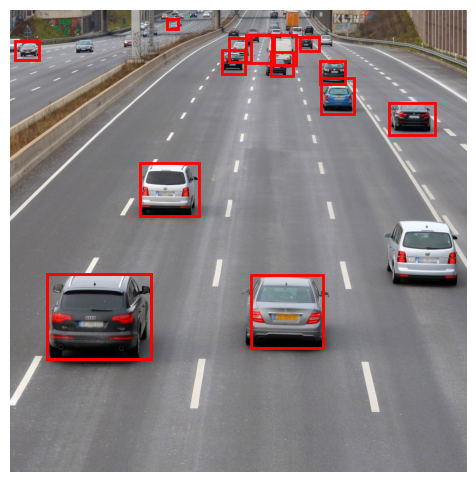

In [42]:
dibujarRectangulo(imageNp, boxes, scores)